In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Set up openjdk paths for spark

# for MacOS
import os
os.environ['JAVA_HOME'] = '/Library/Java/JavaVirtualMachines/openjdk-11.jdk/Contents/Home'
os.environ['PATH'] = f"{os.environ['JAVA_HOME']}/bin:{os.environ['PATH']}"

# Set up logging
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    datefmt="%H:%M:%S"
)

In [3]:
# Imports
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from cider.schemas import (
    CallDataRecordData,
    AntennaData,
    MobileMoneyTransactionData,
)
from cider.utils import generate_all_synthetic_data, validate_dataframe, generate_synthetic_shapefile
from cider.homelocation.schemas import GeographicUnit, GetHomeLocationAlgorithm
from cider.homelocation.core import get_home_locations
from cider.homelocation.plotting import make_location_map

from cider.featurizer.core import preprocess_data, featurize_all_data
from cider.featurizer.dependencies import get_static_diagnostic_statistics, get_timeseries_diagnostic_statistics
from cider.featurizer.plotting import plot_timeseries_diagnostics

from cider.validation_metrics.core import (
    compute_auc_roc_precision_recall_with_percentile_grid, 
    compute_utility_grid, 
    calculate_optimal_utility_and_cash_transfer_size_table,
    calculate_rank_residuals_by_characteristic,
    combine_tables_on_characteristic,)
from cider.validation_metrics.plotting import (
    plot_roc_precision_recall_curves,
    plot_utility_values,
    plot_rank_residual_distributions_per_characteristic_value,
    plot_all_fairness_metrics_per_characteristic_value)

/Users/poornimaramesh/Documents/IDinsight/GiveDirectly_x_Safaricom/cider/.venv/lib/python3.10/site-packages/pydantic/_internal/_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'orm_mode' has been renamed to 'from_attributes'
  warnings.warn(message, UserWarning)
/Users/poornimaramesh/Documents/IDinsight/GiveDirectly_x_Safaricom/cider/.venv/lib/python3.10/site-packages/pydantic/_internal/_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'orm_mode' has been renamed to 'from_attributes'
  warnings.warn(message, UserWarning)


# Step 1: Get data

In [4]:
# Set vars
num_data_points = 100
num_unique_antenna_ids = 10
num_regions = 5
random_seed = 42
keep_optional_columns = False # Remove optional fields to reduce number of features

# Generate synthetic data OR load your own data here
synthetic_data = generate_all_synthetic_data(
    num_data_points=num_data_points,
    num_unique_antenna_ids=num_unique_antenna_ids,
    random_seed=random_seed,
    keep_optional_columns=keep_optional_columns,
)

if keep_optional_columns:
    logging.info("Generated synthetic data with optional columns included")
    shapefile_gdf = generate_synthetic_shapefile(
        antenna_df=synthetic_data[AntennaData],
        num_regions=num_regions,
        random_seed=random_seed,
    )
else:
    logging.info("Generated synthetic data with optional columns excluded")
    shapefile_gdf = None
    synthetic_data.pop(AntennaData) # Remove AntennaData from synthetic data if optional columns are not included

# Validate data
for data_schema, data_df in synthetic_data.items():
    validate_dataframe(data_df, data_schema)

11:55:39 | INFO | cider.utils | Generating synthetic call data record data
/Users/poornimaramesh/Documents/IDinsight/GiveDirectly_x_Safaricom/cider/src/cider/utils.py:201: Warning: Generating synthetic data for CallDataRecordData schema may result in unrealistic duration values and incompatible antenna values.Use the `correct_generated_synthetic_cdr_data` function to correct these values after generation.
  warnings.warn(
11:55:39 | INFO | cider.utils | Correcting synthetic call data record data
11:55:39 | INFO | cider.utils | Generating synthetic mobile money transaction data
/Users/poornimaramesh/Documents/IDinsight/GiveDirectly_x_Safaricom/cider/src/cider/utils.py:208: Warning: Generating synthetic data for MobileMoneyTransactionData schema may result in unrealistic amount values.Use the `correct_generated_synthetic_mobile_money_transaction_data` function to correct these values after generation.
  warnings.warn(
11:55:39 | INFO | cider.utils | Correcting synthetic mobile money tran

# Step 2: Infer transactions around home antenna


In [5]:
if keep_optional_columns:
# Set parameters for home location inference
    geographic_unit = GeographicUnit.SHAPEFILE
    algorithm = GetHomeLocationAlgorithm.COUNT_DAYS

    # Infer home locations
    homes_df = get_home_locations(
        cdr_data=synthetic_data[CallDataRecordData],
        antenna_data=synthetic_data[AntennaData],
        shapefile_data=shapefile_gdf,
        geographic_unit=geographic_unit,
        algorithm=algorithm,
        additional_columns_to_keep=[],
    )

    # Merge home locations with antenna data for plotting
    homes_with_antenna_df = homes_df.merge(
        synthetic_data[AntennaData],
        left_on="caller_antenna_id",
        right_on="antenna_id",
        how="left")

    # Convert to GeoDataFrame
    homes_with_antenna_gdf = gpd.GeoDataFrame(
        homes_with_antenna_df,
        geometry=gpd.points_from_xy(
            x=homes_with_antenna_df['longitude'],
            y=homes_with_antenna_df['latitude'])
    ).set_crs(epsg=4326)

    # Plot home locations
    make_location_map(
        inferred_home_locations=homes_with_antenna_gdf,
        boundaries_shapefile=shapefile_gdf,
        column_to_plot_label="caller_antenna_id",
        column_to_plot_markersize=algorithm.value,
    )

else:
    logging.info("Skipping home location inference and plotting since optional columns were not included in synthetic data")

11:55:41 | INFO | root | Skipping home location inference and plotting since optional columns were not included in synthetic data


# Step 3: Preprocess data

11:55:43 | INFO | cider.featurizer.core | Preprocessing data
11:55:43 | INFO | cider.featurizer.core | Preprocessing data for schema: CallDataRecordData
11:55:43 | INFO | cider.featurizer.core | Preprocessing data for schema: MobileDataUsageData


11:55:43 | INFO | cider.featurizer.core | Preprocessing data for schema: MobileMoneyTransactionData
11:55:43 | INFO | cider.featurizer.core | Preprocessing data for schema: RechargeData


total_transactions=97 num_unique_callers=97 num_unique_recipients=97 num_days=359


/Users/poornimaramesh/Documents/IDinsight/GiveDirectly_x_Safaricom/cider/src/cider/featurizer/plotting.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timeseries_diagnostics_df["day"], rotation=45)


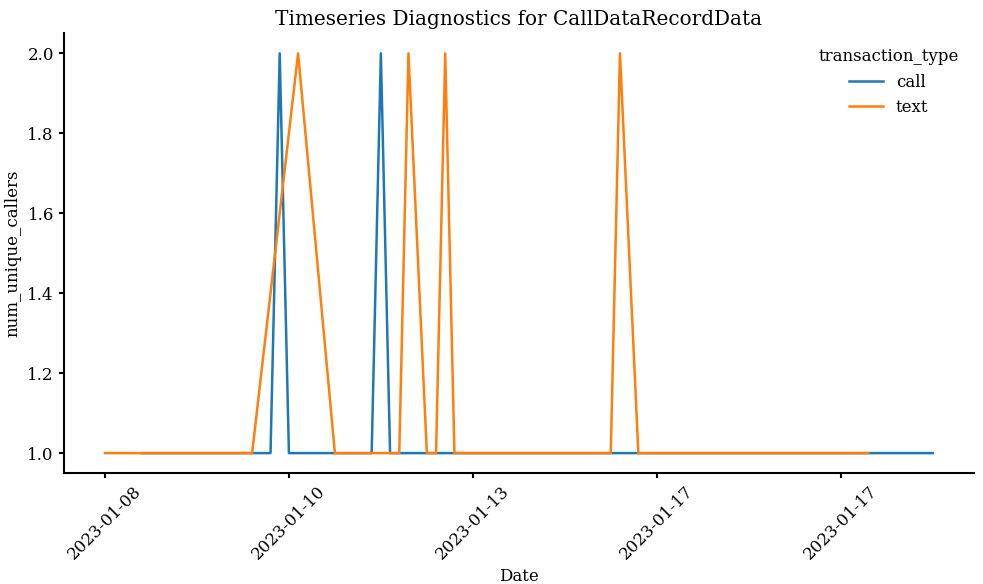

/Users/poornimaramesh/Documents/IDinsight/GiveDirectly_x_Safaricom/cider/src/cider/featurizer/plotting.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timeseries_diagnostics_df["day"], rotation=45)


total_transactions=97 num_unique_callers=97 num_unique_recipients=0 num_days=359


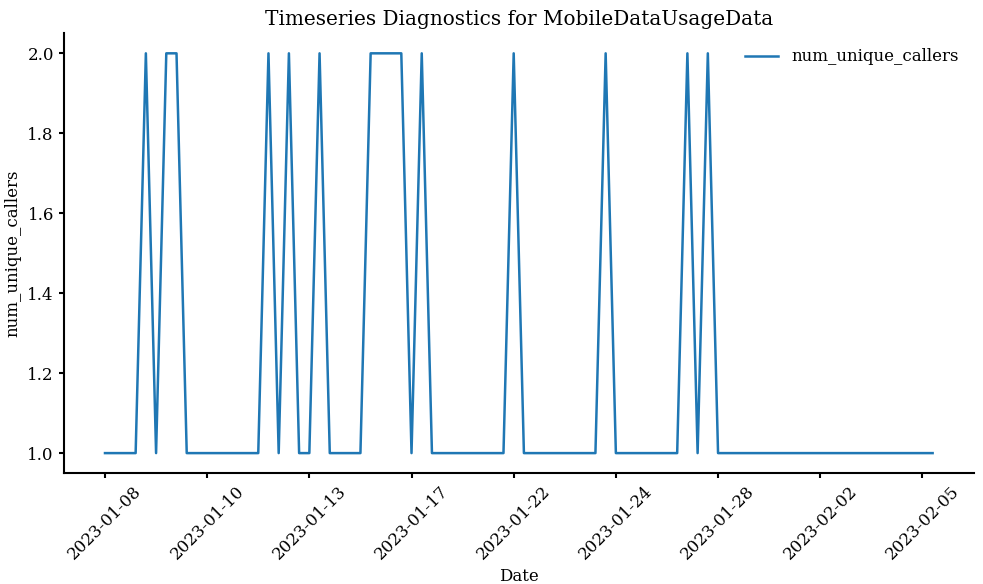

/Users/poornimaramesh/Documents/IDinsight/GiveDirectly_x_Safaricom/cider/src/cider/featurizer/plotting.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timeseries_diagnostics_df["day"], rotation=45)


total_transactions=97 num_unique_callers=97 num_unique_recipients=61 num_days=359


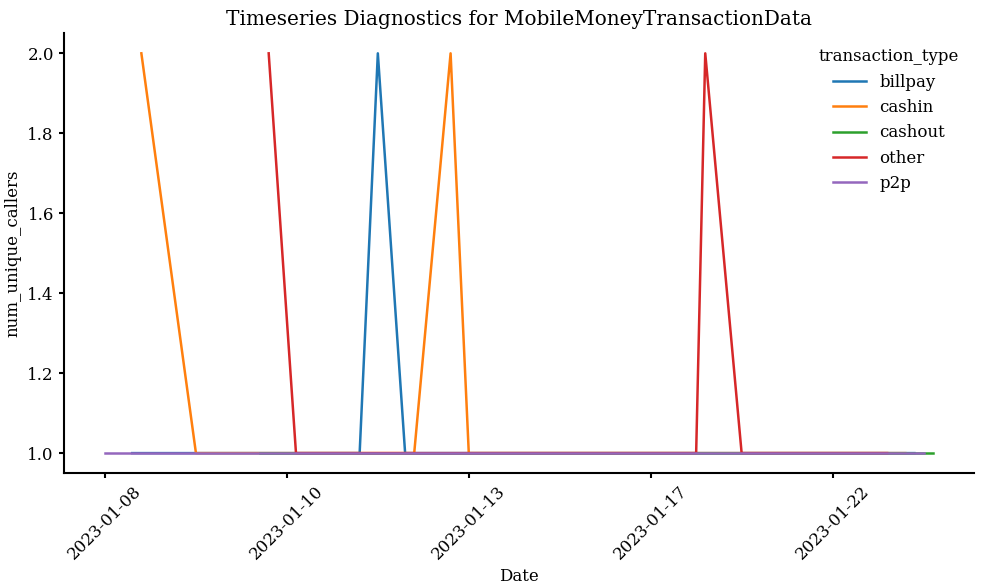

total_transactions=97 num_unique_callers=97 num_unique_recipients=0 num_days=359


/Users/poornimaramesh/Documents/IDinsight/GiveDirectly_x_Safaricom/cider/src/cider/featurizer/plotting.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(timeseries_diagnostics_df["day"], rotation=45)


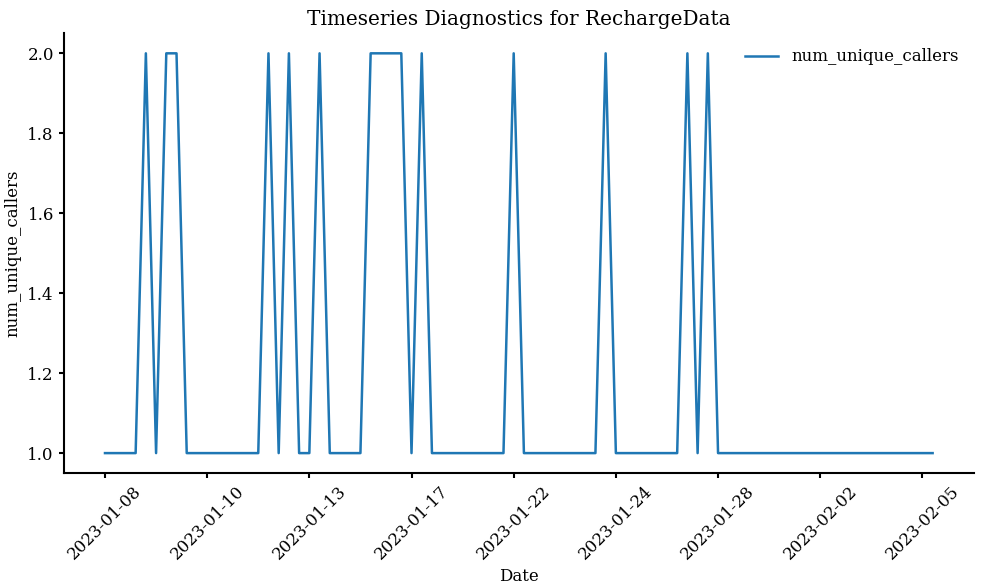

In [6]:
# Set parameters for preprocessing
filter_start_date = datetime.strptime("2022-01-05", "%Y-%m-%d")
filter_end_date = datetime.strptime("2025-01-25", "%Y-%m-%d")
spammer_threshold = 1.75
outlier_day_z_score_threshold = 2.0

# Preprocess data: filtering, spammer removal, outlier day removal
preprocessed_data = preprocess_data(
    data_dict=synthetic_data,
    filter_start_date=filter_start_date,
    filter_end_date=filter_end_date,
    spammer_threshold=spammer_threshold,
    outlier_day_z_score_threshold=outlier_day_z_score_threshold,
)


# Get diagnostics for preprocessed data
static_diagnostics = {}
timeseries_diagnostics = {}
for data_schema, data_df in preprocessed_data.items():
    static_diagnostics[data_schema] = get_static_diagnostic_statistics(data_df)
    print(static_diagnostics[data_schema])

    timeseries_diagnostics[data_schema] = get_timeseries_diagnostic_statistics(data_df)
    fig = plot_timeseries_diagnostics(
        timeseries_diagnostics[data_schema],
        value_column="num_unique_callers",
        groupby_column="transaction_type" if data_schema in [CallDataRecordData, MobileMoneyTransactionData] else None,
        plot_title=f"Timeseries Diagnostics for {data_schema.__name__}",
    )
    plt.show()
    


# Step 4: Featurize data

In [ ]:
# Set parameters for featurization
max_wait_for_convo_in_seconds = 3600
pareto_threshold = 0.8

if keep_optional_columns:
    logging.info("Proceeding with featurization since optional columns were included in synthetic data")
    # Prepare antenna_data
    antenna_gdf = gpd.GeoDataFrame(
        synthetic_data[AntennaData],
        geometry=gpd.points_from_xy(
            x=synthetic_data[AntennaData]['longitude'],
            y=synthetic_data[AntennaData]['latitude'])
    ).set_crs(epsg=4326)
    antennas_merged_shp = gpd.sjoin(antenna_gdf, shapefile_gdf, how='left', predicate='within')[['antenna_id', 'region']]
    antennas_merged_shp.region.fillna('Unknown', inplace=True)
    antennas_df = antennas_merged_shp.merge(
        synthetic_data[AntennaData],
        on="antenna_id")

    preprocessed_data[AntennaData] = antennas_df

# Featurize all data
features_df = featurize_all_data(
    preprocessed_data=preprocessed_data,
    max_wait_for_convo_in_seconds=max_wait_for_convo_in_seconds,
    pareto_threshold=pareto_threshold,
)


11:55:45 | INFO | cider.featurizer.core | Featurizing CDR data


26/02/25 11:55:47 WARN Utils: Your hostname, Poornimas-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 192.168.1.151 instead (on interface en0)
26/02/25 11:55:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/25 11:55:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
11:55:54 | INFO | cider.featurizer.core | Identifying daytime and weekend interactions
11:55:54 | INFO | cider.featurizer.core | Swapping caller and recipient IDs for recipient-centric view
11:55:54 | INFO | cider.featurizer.core | Identifying and tagging conversations
11:55:55 | INFO | cider.featurizer.core | Calculating active days per caller
11:55:56 | INFO | cider.featurizer.core | Calculating number of unique contacts per caller
11:55:57 | INFO | cider.featurizer.cor

# Step 6: Fit models

In [7]:
# Prepare features_df for modeling or analysis
features_df_clean = features_df.dropna(axis=1, how='any')

# Make fake groundtruth consumption values
groundtruth_consumption = np.random.rand(len(features_df_clean)) * 10
weights = np.random.randint(10, 100, size=len(features_df_clean))

# Train-test split
X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(features_df_clean, groundtruth_consumption, weights, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train.drop(columns="caller_id"), y_train)

# Get predictions
y_pred_train = model.predict(X_train.drop(columns="caller_id"))
y_pred_test = model.predict(X_test.drop(columns="caller_id"))

# Prepare data for validation metrics
consumption_data = pd.DataFrame({
    'household_id': X_test['caller_id'],
    'groundtruth_consumption': y_test,
    'weight': weights_test,
    'proxy_consumption': y_pred_test,
})



NameError: name 'features_df' is not defined

# Step 7: Evaluate model predictions

In [6]:
fixed_groundtruth_percentile = 20  # Bottom 20% are considered "low-income"

# Simulate additional characteristics for fairness analysis
np.random.seed(42)
allowed_gender_values = {'male', 'female', 'other'}
consumption_data_w_gender = consumption_data.copy()
consumption_data_w_gender['characteristic'] = np.random.choice(list(allowed_gender_values), size=len(consumption_data_w_gender))

NameError: name 'consumption_data' is not defined

In [ ]:

# AUC ROC
auc_roc_precision_recall_df = compute_auc_roc_precision_recall_with_percentile_grid(
    consumption_data,
    fixed_groundtruth_percentile,
    100)

# Plot ROC Curve
fig, ax = plot_roc_precision_recall_curves(auc_roc_precision_recall_df, fixed_groundtruth_percentile)
fig  

In [ ]:
# Compute utility grid
cash_transfer_at_ubi_rate = 0.01 * consumption_data['weight'].sum()
utility_grid_df = compute_utility_grid(
    consumption_data,
    cash_transfer_amount=cash_transfer_at_ubi_rate,
    num_grid_points=99,
    constant_relative_risk_aversion=3.0)

# Calculate optimal utility and cash transfer size table
optimal_utility_df = calculate_optimal_utility_and_cash_transfer_size_table(
    consumption_data,
    cash_transfer_amount=cash_transfer_at_ubi_rate,
    num_grid_points=10,
    constant_relative_risk_aversion=3.0
)

# Plot utility values
fig, ax = plot_utility_values(
    utility_grid_df, 
    optimal_utility_df.loc["proxy_consumption", "optimal_population_percentile"],
    optimal_utility_df.loc["proxy_consumption", "maximum_utility"],
    cash_transfer_at_ubi_rate, 3)
fig

In [ ]:
# Rank residuals per characteristic
rank_residual_df = calculate_rank_residuals_by_characteristic(
    consumption_data_w_gender)

# Plot rank residual distributions per characteristic value
fig, ax = plot_rank_residual_distributions_per_characteristic_value(rank_residual_df, "Gender")
fig

In [ ]:
# Compute all other fairness metrics per characteristic value
combined_results, statistics = combine_tables_on_characteristic(
    consumption_data_w_gender,
    50
)

# Plot all fairness metrics per characteristic value
fig, ax = plot_all_fairness_metrics_per_characteristic_value(combined_results, statistics, "Gender", color="blue")
fig